# 1. See how the baseline and cognitive load signals look like

In [20]:
from data_utils import load_device_signals, create_windows

import matplotlib.pyplot as plt
import numpy as np

In [21]:
signals_b = load_device_signals(participant_id=3, condition='baseline')
print(signals_b['bvp'].shape)

# To stack into a design matrix s(t) ∈ R^3:
import numpy as np
s_t = signals_b["bvp"]
# s_t = np.vstack([signals_b["bvp"], signals_b["eda"], signals_b["temp"]]).T
print(s_t.shape)  # (time steps, 3)

(5684,)
(5684,)


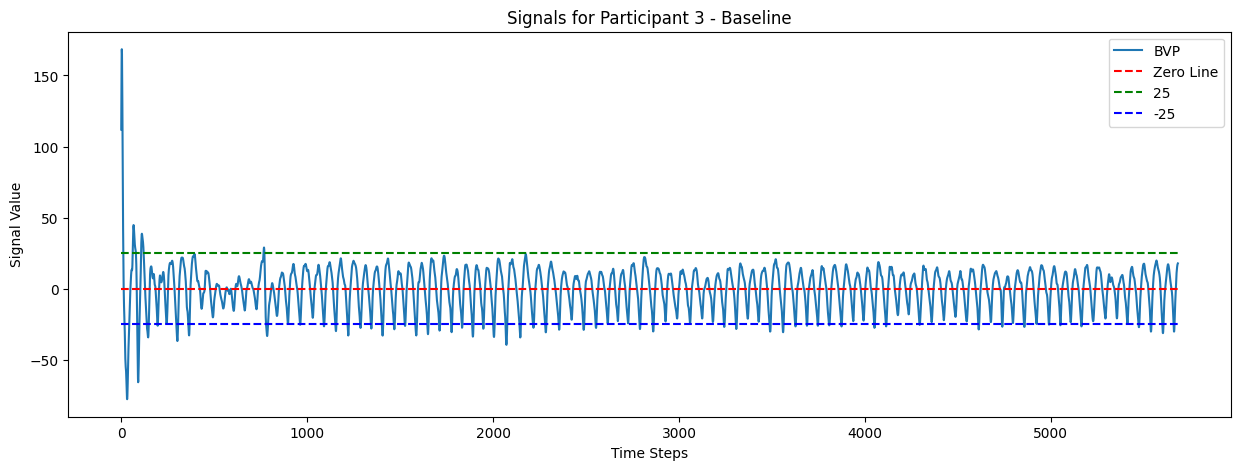

In [22]:
plt.figure(figsize=(15, 5))
plt.plot(s_t, label='BVP')
plt.hlines(0, xmin=0, xmax=s_t.shape[0], colors='r', linestyles='--', label='Zero Line')
plt.hlines(25, xmin=0, xmax=s_t.shape[0], colors='g', linestyles='--', label='25')
plt.hlines(-25, xmin=0, xmax=s_t.shape[0], colors='b', linestyles='--', label='-25')
plt.legend()
plt.title('Signals for Participant 3 - Baseline')
plt.xlabel('Time Steps')
plt.ylabel('Signal Value')
plt.show()

In [23]:
signals_b_c = load_device_signals(participant_id=3, condition='cognitive_load')
print(signals_b_c['bvp'].shape)

# To stack into a design matrix s(t) ∈ R^3:
import numpy as np
s_t_c = signals_b_c["bvp"]
# s_t = np.vstack([signals_b["bvp"], signals_b["eda"], signals_b["temp"]]).T
print(s_t_c.shape)  # (time steps, 3)

(8002,)
(8002,)


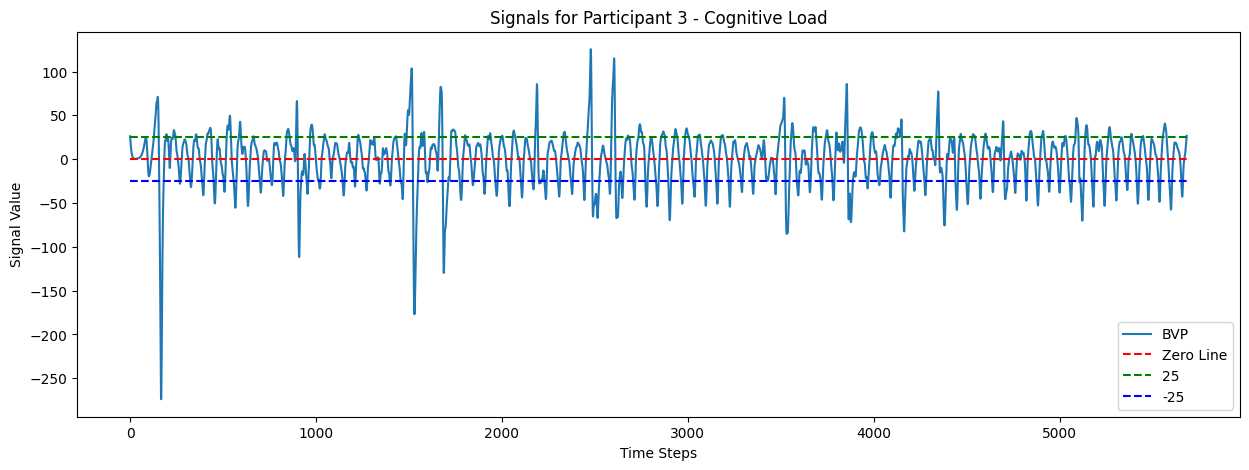

In [24]:
uniform_length = min(s_t.shape[0], s_t_c.shape[0])
s_t_c_uniform = s_t_c[:uniform_length]

plt.figure(figsize=(15, 5))
plt.plot(s_t_c_uniform, label='BVP')
plt.hlines(0, xmin=0, xmax=s_t_c_uniform.shape[0], colors='r', linestyles='--', label='Zero Line')
plt.hlines(25, xmin=0, xmax=s_t_c_uniform.shape[0], colors='g', linestyles='--', label='25')
plt.hlines(-25, xmin=0, xmax=s_t_c_uniform.shape[0], colors='b', linestyles='--', label='-25')
plt.legend()
plt.title('Signals for Participant 3 - Cognitive Load')
plt.xlabel('Time Steps')
plt.ylabel('Signal Value')
plt.show()

# 2. Feature extraction

In [25]:
def max_amp(window):
    return (window.max() - window.min()) / 2

def sign_changes(window):
    derivative = np.diff(window)
    return np.sum(np.diff(np.sign(derivative)) != 0)

def mean_peak_width(signal):
    peaks, _ = find_peaks(signal, prominence=1)  # Adjust prominence as needed
    if len(peaks) == 0:
        return 0
    widths, _, _, _ = peak_widths(signal, peaks, rel_height=0.5)
    return np.mean(widths)

def mean_peak_prominence(signal):
    peaks, _ = find_peaks(signal, prominence=1)  # Adjust prominence as needed
    if len(peaks) == 0:
        return 0
    prominences = peak_prominences(signal, peaks)[0]
    return np.mean(prominences)

def post_peak_area(signal, time_window=50):
    peaks, _ = find_peaks(signal)
    if len(peaks) == 0:
        return 0
    main_peak_idx = peaks[np.argmax(signal[peaks])]
    right_end = min(len(signal), main_peak_idx + time_window)
    return np.sum(np.abs(signal[main_peak_idx:right_end]))

def pre_peak_area(signal, time_window=50):
    peaks, _ = find_peaks(signal)
    if len(peaks) == 0:
        return 0
    main_peak_idx = peaks[np.argmax(signal[peaks])]
    left_start = max(0, main_peak_idx - time_window)
    return np.sum(np.abs(signal[left_start:main_peak_idx]))

def create_features(window):
    return {
        'max_amp': max_amp(window),
        'sign_changes': sign_changes(window),
        'mean_peak_width': mean_peak_width(window),
        'mean_peak_prominence': mean_peak_prominence(window),
        'post_peak_area': post_peak_area(window),
        'pre_peak_area': pre_peak_area(window)
    }

In [26]:
window_size = 256
step_size = 128

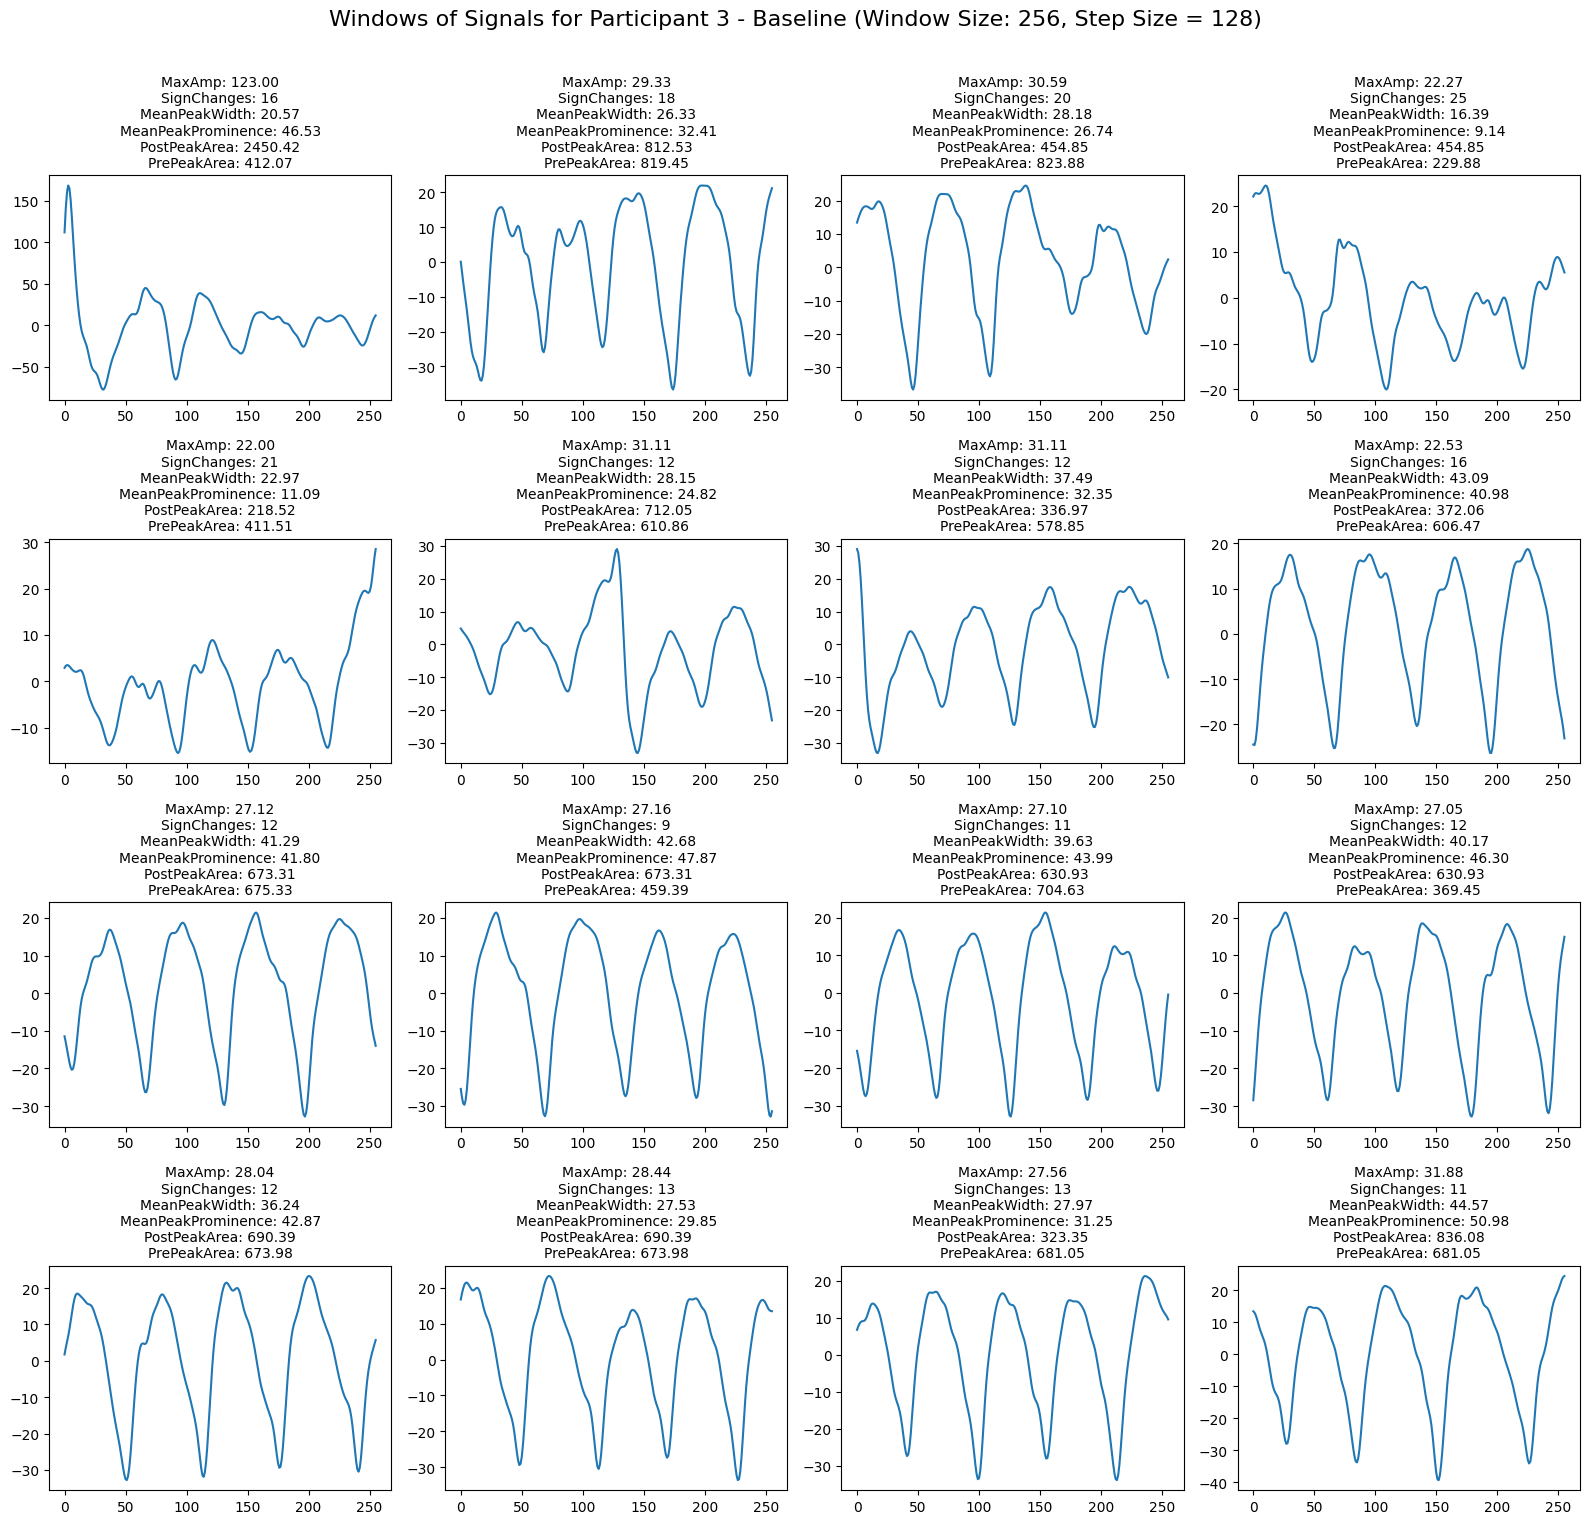

In [27]:
s_t_windows = create_windows(s_t, window_size=window_size, step_size=step_size)

fig, ax = plt.subplots(4, 4, figsize=(16, 16))
ax = ax.flatten()
for i in range(16):
    ax[i].plot(s_t_windows[i])
    features = create_features(s_t_windows[i])
    ax[i].set_title(f'MaxAmp: {features["max_amp"]:.2f}\nSignChanges: {features["sign_changes"]}\nMeanPeakWidth: {features["mean_peak_width"]:.2f}\nMeanPeakProminence: {features["mean_peak_prominence"]:.2f}\nPostPeakArea: {features["post_peak_area"]:.2f}\nPrePeakArea: {features["pre_peak_area"]:.2f}', fontsize=10)
fig.suptitle(f'Windows of Signals for Participant 3 - Baseline (Window Size: {window_size}, Step Size = {step_size})', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

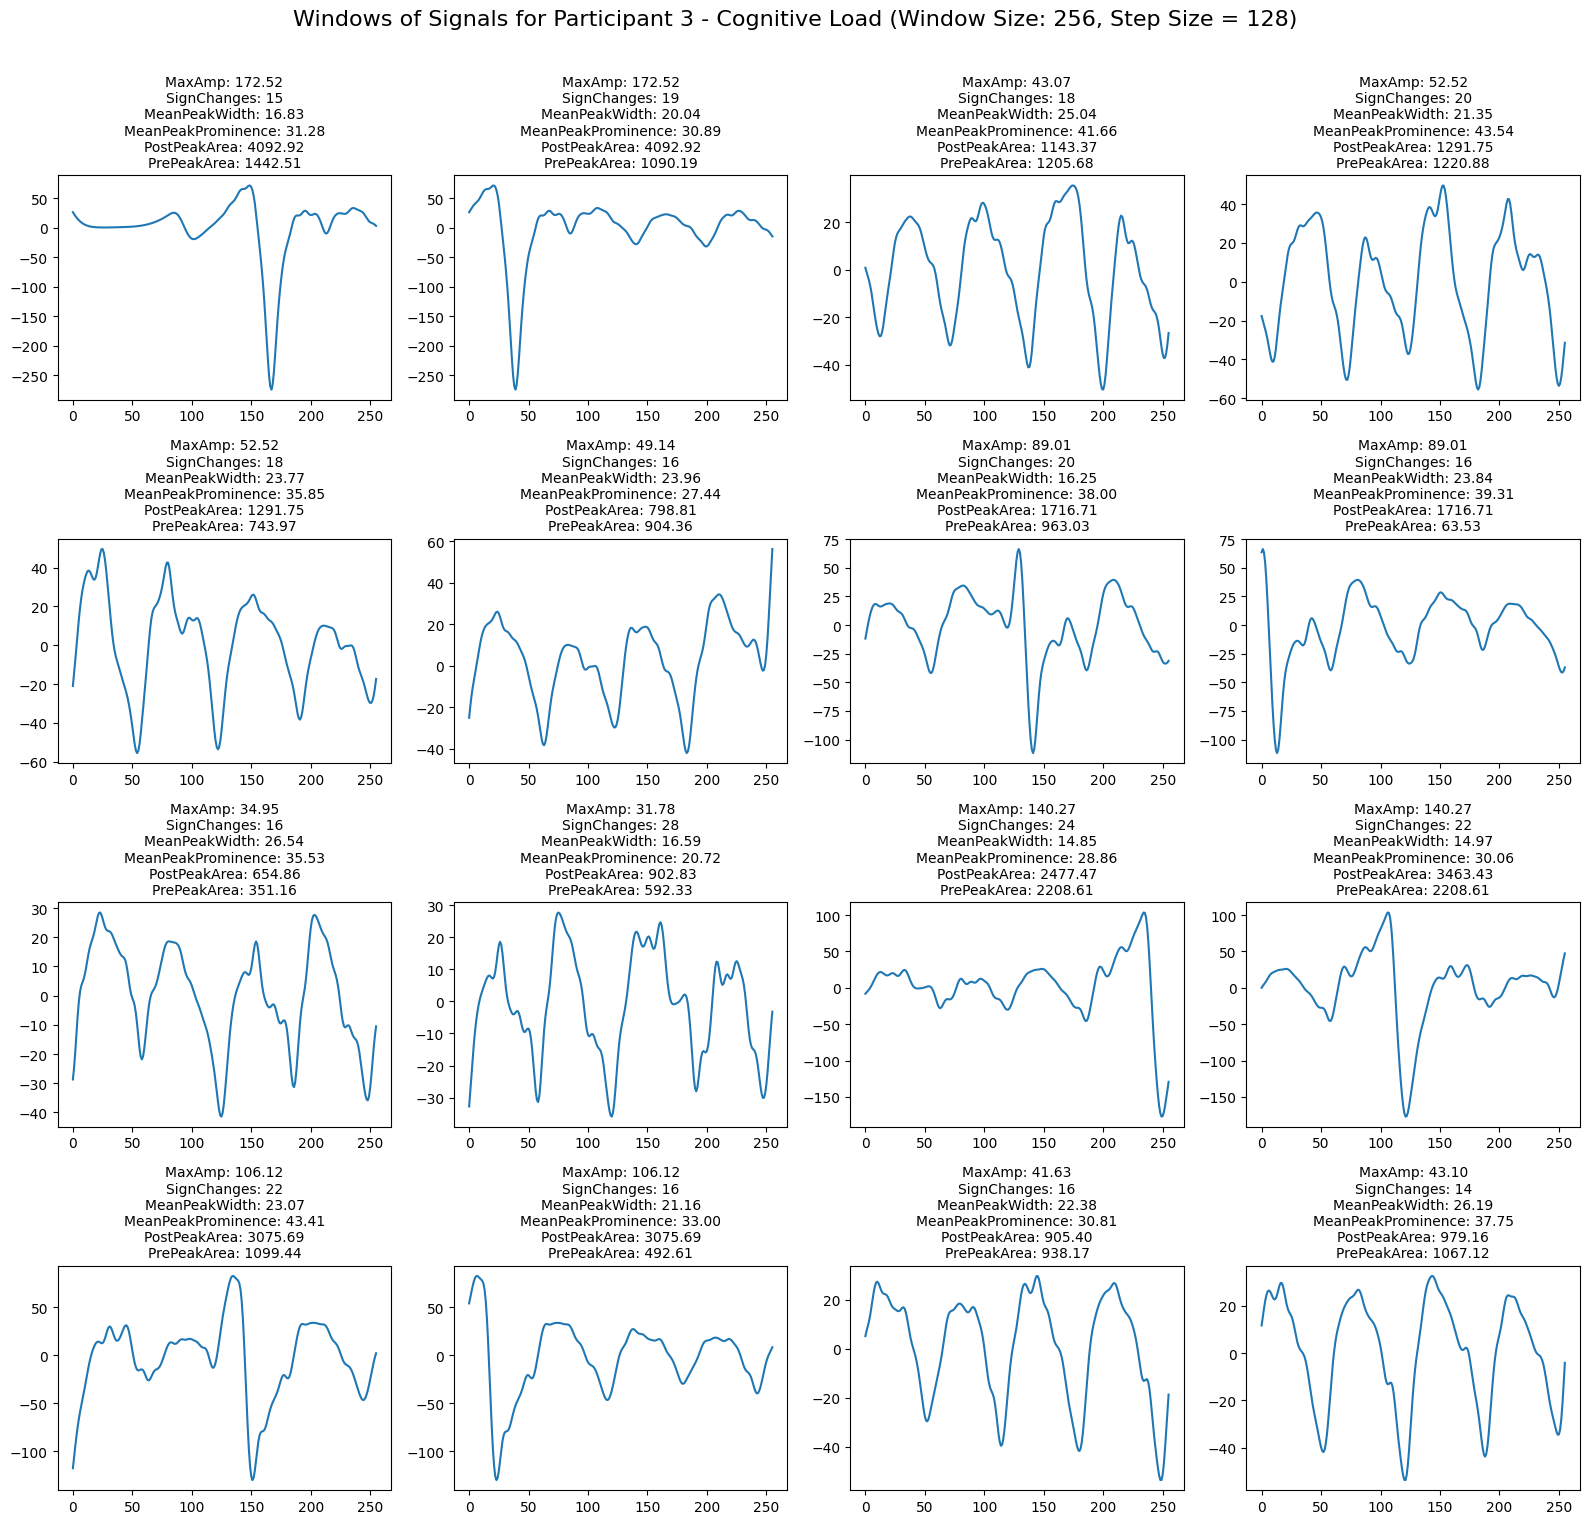

In [28]:
s_t_c_windows = create_windows(s_t_c, window_size=window_size, step_size=step_size)

fig, ax = plt.subplots(4, 4, figsize=(16, 16))
ax = ax.flatten()
for i in range(16):
    ax[i].plot(s_t_c_windows[i], label=f'Window {i+1}')
    features = create_features(s_t_c_windows[i])
    ax[i].set_title(f'MaxAmp: {features["max_amp"]:.2f}\nSignChanges: {features["sign_changes"]}\nMeanPeakWidth: {features["mean_peak_width"]:.2f}\nMeanPeakProminence: {features["mean_peak_prominence"]:.2f}\nPostPeakArea: {features["post_peak_area"]:.2f}\nPrePeakArea: {features["pre_peak_area"]:.2f}', fontsize=10)
fig.suptitle(f'Windows of Signals for Participant 3 - Cognitive Load (Window Size: {window_size}, Step Size = {step_size})', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

In [29]:
from scipy.stats import ttest_ind
feature_names = ["max_amp", "sign_changes", "mean_peak_width", "mean_peak_prominence", "post_peak_area", "pre_peak_area"]
features_b = np.array([create_features(window) for window in s_t_windows])
features_c = np.array([create_features(window) for window in s_t_c_windows])
for feature_name in feature_names:
    features_b_particular_feature = [window_features[feature_name] for window_features in features_b]
    features_c_particular_feature = [window_features[feature_name] for window_features in features_c]
    t_stat, p_value = ttest_ind(features_b_particular_feature, features_c_particular_feature, equal_var=False, trim=0.1)
    print(f"{feature_name}: t-statistic = {t_stat}, p-value = {p_value}")

max_amp: t-statistic = -10.385074439306587, p-value = 2.8118269325806783e-14
sign_changes: t-statistic = -4.754030503713769, p-value = 8.468674608410498e-06
mean_peak_width: t-statistic = 7.0228337459224015, p-value = 6.72929292864725e-10
mean_peak_prominence: t-statistic = -4.260397011963726, p-value = 5.5937102399239895e-05
post_peak_area: t-statistic = -7.997166683815882, p-value = 8.862673379085817e-11
pre_peak_area: t-statistic = -7.44450611744259, p-value = 4.326701409140693e-10


In [30]:
# Features: already computed
X_b = np.array([list(window_feat.values()) for window_feat in features_b])  # Baseline
X_c = np.array([list(window_feat.values()) for window_feat in features_c])  # Cogload

# Labels
y_b = np.zeros(len(X_b))  # Baseline = 0
y_c = np.ones(len(X_c))   # Cognitive Load = 1

# Combine
X = np.vstack([X_b, X_c])
y = np.concatenate([y_b, y_c])

feature_names = list(features_b[0].keys())  # Ensure consistent order


In [31]:
feature_names

['max_amp',
 'sign_changes',
 'mean_peak_width',
 'mean_peak_prominence',
 'post_peak_area',
 'pre_peak_area']

# 3. Feature selection via MDI in Random Forest

Classification Report:
               precision    recall  f1-score   support

         0.0       0.89      1.00      0.94        17
         1.0       1.00      0.92      0.96        25

    accuracy                           0.95        42
   macro avg       0.95      0.96      0.95        42
weighted avg       0.96      0.95      0.95        42

Confusion Matrix:


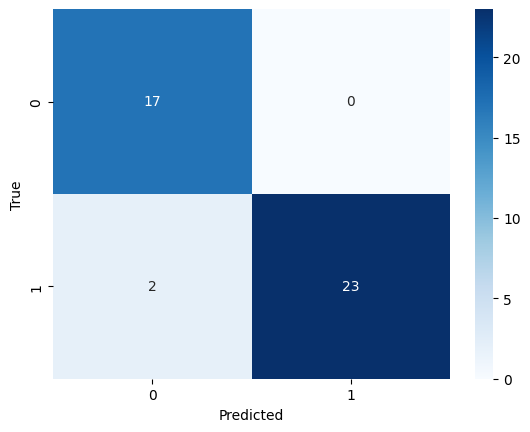

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)

# Train
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Evaluate
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


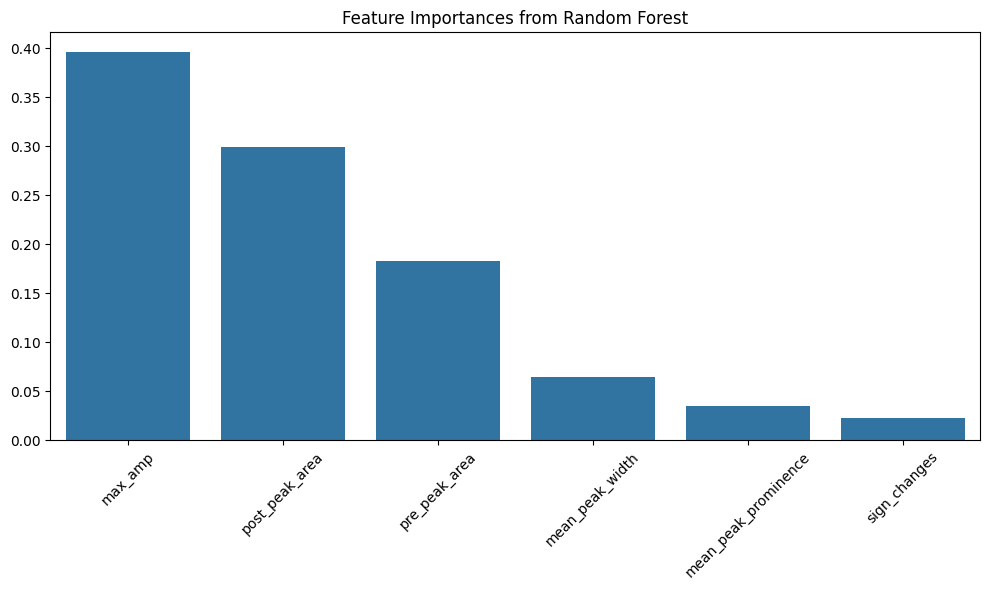

In [33]:
import pandas as pd

importances = clf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=[feature_names[i] for i in sorted_idx], y=importances[sorted_idx])
plt.xticks(rotation=45)
plt.title("Feature Importances from Random Forest")
plt.tight_layout()
plt.show()


In [34]:
import pandas as pd
import numpy as np

df = pd.DataFrame(X, columns=feature_names)
selected_features = ["max_amp", "post_peak_area", "pre_peak_area"]
df = df[selected_features].round(2)
df["label"] = y

df.to_csv("features_for_sirus.csv", index=False)

# 4. Rule-based classification using SIRUS

In [35]:
def rule(window_features):
    return 1 if window_features['max_amp'] >= 30.59 and window_features['post_peak_area'] >= 798.81 else 0

In [36]:
df["rule_label"] = df.apply(rule, axis=1)

In [37]:
df

,max_amp,post_peak_area,pre_peak_area,label,rule_label
0,123.00,2450.42,412.07,0.0,1
1,29.33,812.53,819.45,0.0,0
2,30.59,454.85,823.88,0.0,0
3,22.27,454.85,229.88,0.0,0
4,22.00,218.52,411.51,0.0,0
...,...,...,...,...,...
99,42.72,977.01,299.81,1.0,1
100,45.32,1112.50,1113.27,1.0,1
101,47.44,1112.50,1113.27,1.0,1
102,46.68,1099.84,1172.41,1.0,1


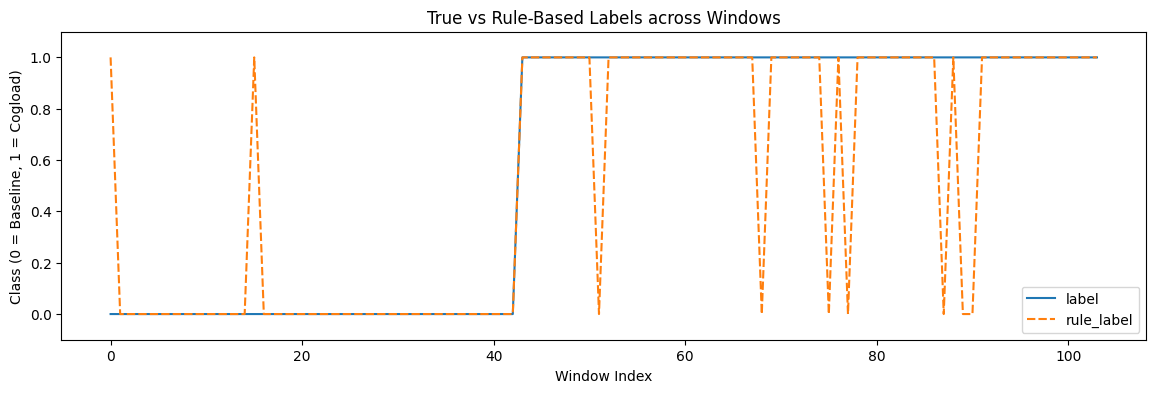

In [38]:
plt.figure(figsize=(14, 4))
sns.lineplot(data=df[['label', 'rule_label']])
plt.xlabel("Window Index")
plt.ylabel("Class (0 = Baseline, 1 = Cogload)")
plt.title("True vs Rule-Based Labels across Windows")
plt.legend()
plt.ylim(-0.1, 1.1)
plt.show()